# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
**A model is linear if the parameters are multiplied by either constants or variables in the format X*B. A linear model does not need to follow the conventional y = mx+b or result in a straight line like I initially thought. The parameter must also not be inside a function, such as log(B). They are like linear combinations of predictors so B (the parameter) must be the multiplier.**
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?) 
**If the typical model is y = B0 + B1(X), then B0 would be the intercept of the model. It represents the reference category. Therefore, when the other dummy variables are 0, y = B0. The feature represented by B0 would be equal to the predicted y. The coefficients are the B. It means that, holding all other parameters constant, increasing X by 1 would change the predicted y by B.**
3. Can linear regression be used for classification? Explain why, or why not.
**Yes, however, the predicted y could be any number even outside the range of 0 and 1, which makes it hard classfiy. For classification, the probability needs to between 0 and 1, especially when the classification is between binary labels. In addition, linear regression assumes normally distributed errors and constant variance. A logistic regression however, can solve this issue by forcing the prediction to stay betwen 0 and 1.**
4. What are signs that your linear model is over-fitting?
**A model is overfitting when the testing data fits the training data so much that it does not work for other pieces of data. Therefore, when looking for the MSE, an overfitting model would have very low MSE with their training data and higher MSE with any other datasets. The model also has high variance and low bias because of the bias/variance trade off.**
5. Clearly explain multi-colinearity using the two-stage least squares technique.
**Multicolinearity happens when 2 features are highly correlated, so much so that we cannot say which variable causes the predicted y to be what it is. We cannot tell how much the predicted y is affected by one variable vs another.**
**Two stage least squares technique isolates one of the variable to test the effects of it without the variable that is highly correlated with it. It uses an instrument variable, which does not directly affect y_hat but does correlate with the problem variable, and regresses on that to find the predicted_problem_variable. Then it uses that predicted_problem_variable in a regression to find the actual y_hat. Since this new predicted_problem_variable is explained by the instrument variable, it no longer correlates with the other problem variable. The end result is the causal effect of the predicted_problem_variable on y_hat.**
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
**To capture the non-linear relationship between y and x, we can add transformations that make the model non-linear but allow curves and stuff to be captured. Can also add interaction terms to see combined effects and how that impacts y_hat.**
7. What is the interpretation of the slope coefficient in a linear regression?
**The slope coefficient how much the y would change for every 1 unit increase in X. With multiple parameters (and therefore multiple slope coefficients), it would be the change in y for every increase in X holding all other variables constant.**
8. Compare the train/test split and $k$-fold cross validation.
**Train/test only splits the dataset into 2 and trains on only one 1 testing group. K-fold cross validations performs essential multiple train/tests but each time, the training dataset is a different protion of the whole dataset. This uses all of the observations and calculates with lower variance in MSE because it takes into consideration k combinations of train test datasets.**
9. How is the $k$ in $k$-fold cross validation typically selected?
**Higher K typically takes more computational cost while lower K can be less reliable. So the optimal K is somewhere in between. Typicall 5 or 10 folds is good.**

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df1 = pd.read_csv("data/Q1_clean.csv")
df1.columns = df1.columns.str.strip()
df1.columns

Index(['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type',
       'Room Type'],
      dtype='object')

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.\
**Manhattan is the most expensive neighbourhood.**

In [18]:
df1.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


<Axes: xlabel='Price', ylabel='Density'>

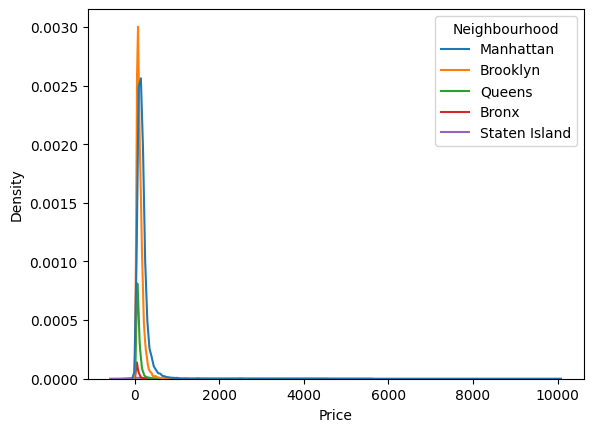

In [22]:
# Normal KDE
sns.kdeplot(df1, x = "Price", hue = "Neighbourhood")

<Axes: xlabel='log_price', ylabel='Density'>

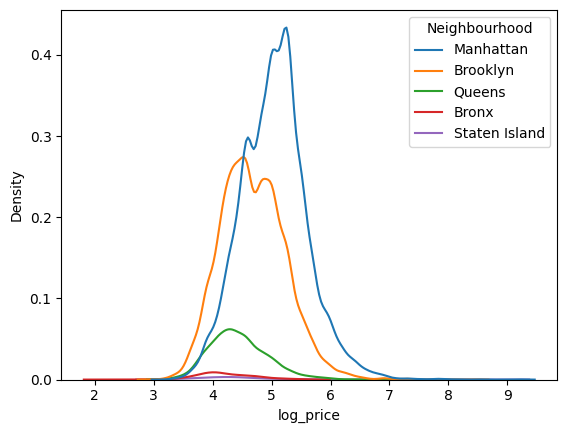

In [23]:
# Log KDE
df1["log_price"] = np.log(df1["Price"])
sns.kdeplot(data = df1, x = "log_price", hue = "Neighbourhood")

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?\
**The coefficients match the one made by grouping, with Manhattan having the highest coefficient and Queens having the lowest. Bronx would have been the lowest however, it was dropped in order to get rid of multi-colinearity (baseline variable). The conditional group means match the estimated coeficients related.**

In [82]:
from sklearn.linear_model import LinearRegression
#print(df1["Neighbourhood"].value_counts())

y_2 = df1["Price"]
X_2 = pd.get_dummies(df1['Neighbourhood'], dtype = "int", drop_first = True)
#sklearn adds an intercept
model_2 = LinearRegression()
model_2 = model_2.fit(X_2, y_2)

pd.DataFrame({'variable':model_2.feature_names_in_, 'coefficient':model_2.coef_ })

,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


Interpretation from chat:
| Neighborhood  | Coefficient | Meaning                                         |
| ------------- | ----------- | ----------------------------------------------- |
| Brooklyn      | +52.47      | Brooklyn is $52.47 more than Bronx (on average) |
| Manhattan     | +108.39     | Manhattan is $108.39 more than Bronx            |
| Queens        | +21.58      | Queens is $21.58 more than Bronx                |
| Staten Island | +70.89      | Staten Island is $70.89 more than Bronx         |


3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.\
**For each 1 point increase in the review scores rating, the price increases by $1.02 units.**

In [83]:
y_3 = df1[["Price"]]
X_3 = df1[["Review Scores Rating"]]

model_3 = LinearRegression()
model_3 = model_3.fit(X_3, y_3)

print("Intercept:", model_3.intercept_)
print("Slope:", model_3.coef_)

Intercept: [60.87839066]
Slope: [[1.0208266]]


4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?\
**The slope coefficient went up by about 0.06. Previous model did not account for the separate influence Neighbourhood had on the price. Instead, the effect was mixed in with the Review Scores Rating. Once that separate effect was added, the individual slope coefficient for Review Scores Rating became stronger because the confounding Neighbourhood effect was removed. This is called ommited variable bias where an important variable (Neighbourhood) was left out.**

In [84]:
# Categorical variables need to be one-hot-encoded. To avoid multi-colinearity, drop the first category
y_4 = df1[["Price"]]
X_4 = pd.concat([df1[[ "Review Scores Rating"]], pd.get_dummies(df1["Neighbourhood"], drop_first = True)], axis = 1)

model_4 = LinearRegression()
model_4 = model_4.fit(X_4, y_4)

print("Intercept:", model_4.intercept_)
print("Slope:", model_4.coef_)

Intercept: [-23.81256101]
Slope: [[  1.08111648  51.70424016 108.22873657  21.69459958  71.76655213]]


5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?\
**The slopes are not similar across neighborhoods. While the first two are similar, the third is negative, and the fourth is signicantly negative. Therefore the effect of review on price is not the same across neighborhoods. The positive coefficients for the first 2 boroughs suggests that positive reviews correlate with higher prices. The third borough (Queens) correlates moderately with higher prices. The fourth borough (Staten Island) is strongly negatively correlated, however, this could be due to it having significantly lower sample size (n = 96) than the other boroughs. This results in the model being overfit for Staten Island causing it to be sensative to smaller data.**

In [86]:
y_5 = df1["Price"]

dummies = pd.get_dummies(df1["Neighbourhood"], drop_first = True)
interactions = dummies.mul(df1["Review Scores Rating"], axis=0)
# change name of interaction cols
interactions.columns = [f"{col}_interaction" for col in interactions.columns]
X_5 = pd.concat([df1[["Review Scores Rating"]], dummies, interactions], axis = 1)

model_5 = LinearRegression()
model_5 = model_5.fit(X_5, y_5)

print("Intercept: ", model_5.intercept_)
print("Slope: ", model_5.coef_)

Intercept:  22.638384922064745
Slope:  [ 5.74310949e-01 -1.63929902e+01  4.13154289e+01  2.82597013e+01
  2.96307104e+03  7.41165266e-01  7.29703445e-01 -7.22943454e-02
 -3.18317476e+01]


6. Use cross validation to evaluate the models from parts 4, 5, and 6.\
**Changed to 3, 4, 5. The mean and standard deviation across all 3 models are about the same. #4 had the lowest average MSE among the 3, however, which may indicate that it is a slightly more reliable model.**


In [97]:
## Scikit Implementation: Mostly Automatic

from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # Create folds
# 3
scores = cross_val_score( # Conduct kfcv:
    model_3,X_3,y_3, # Model and data
    cv=kfold, # Folds
    scoring="neg_mean_squared_error" # Loss function
)
scores = -1*scores
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))
print()

# 4
scores = cross_val_score( # Conduct kfcv:
    model_4,X_4,y_4, # Model and data
    cv=kfold, # Folds
    scoring="neg_mean_squared_error" # Loss function
)
scores = -1*scores
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))
print()

# 5
scores = cross_val_score( # Conduct kfcv:
    model_5,X_5,y_5, # Model and data
    cv=kfold, # Folds
    scoring="neg_mean_squared_error" # Loss function
)
scores = -1*scores
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))


Fold scores: [14525.62587895 18785.03156182 23315.65390815 21485.08112418
 17377.37412282 16911.65764952 66505.14612181 12010.92688963
 13867.65309739 16010.97323341]
Mean score: 22079.51235876914
Median score: 17144.515886169527
Std dev: 15158.786803772264

Fold scores: [13328.8844614  17923.91602978 22359.73425128 20638.78463036
 16213.77913811 15968.25148456 65543.4120206  11112.83183507
 12726.79546542 14924.58455652]
Mean score: 21074.09738730937
Median score: 16091.015311334519
Std dev: 15184.49009301701

Fold scores: [13651.39402828 18041.63445512 22439.57433037 21154.75504879
 17344.73843257 16072.72994399 65397.17732163 11351.99120315
 12853.37506753 15040.17830152]
Mean score: 21334.754813295083
Median score: 16708.73418827802
Std dev: 15058.050935045354


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made


1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?\
**"Price" has a mean of 97600, a median of 66650 indicating that Price is skewed right. The standard devidation is 367323 suggesting high variability. Prices range from 188000 to 2941000.**
**SUVs have the highest average price, however, Sedans have the highest price within this dataset. SUVs and Sedans also have the highest standard deviations.**

       Unnamed: 0    Make_Year   Mileage_Run  Seating_Capacity         Price
count  976.000000   976.000000    976.000000        976.000000  9.760000e+02
mean   488.500000  2016.963115  41571.195697          5.095287  7.410195e+05
std    281.891232     2.818742  24390.995134          0.446224  3.673234e+05
min      1.000000  2011.000000   1117.000000          4.000000  1.880000e+05
25%    244.750000  2015.000000  22676.750000          5.000000  4.757500e+05
50%    488.500000  2017.000000  37570.500000          5.000000  6.665000e+05
75%    732.250000  2019.000000  57421.250000          5.000000  8.830000e+05
max    976.000000  2022.000000  99495.000000          8.000000  2.941000e+06


<Axes: xlabel='Price', ylabel='Density'>

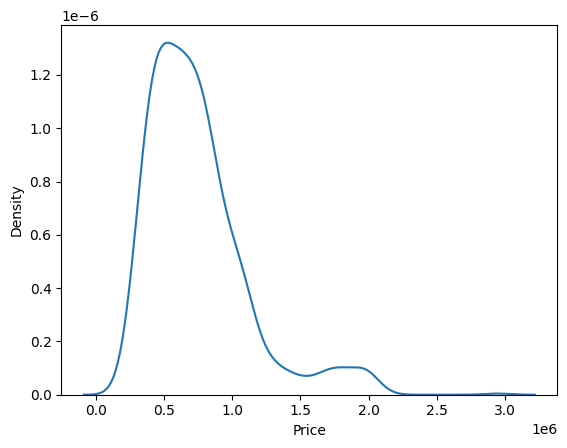

In [108]:
cdf = pd.read_csv("data/cars_hw.csv")
print(cdf.describe())
sns.kdeplot(data = cdf["Price"])

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


<Axes: xlabel='Price', ylabel='Density'>

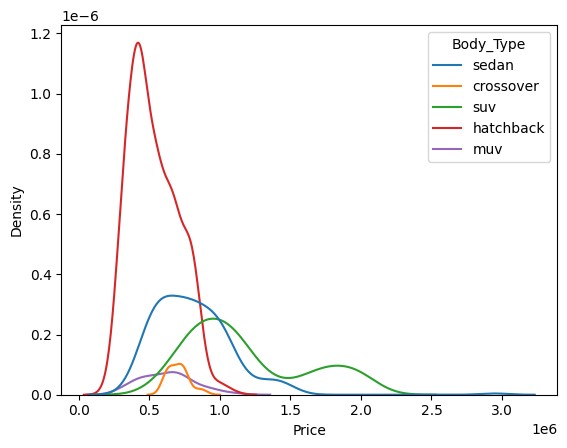

In [115]:
print(cdf.groupby("Body_Type")["Price"].describe())
sns.kdeplot(data = cdf, x = "Price", hue = "Body_Type")

 2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?\
 **The slope coefficient is 59267.99803672. This means that as the number of seating capacity increases, the price of the car increases by about $59267.99.**\
 **After using one hot encoding, the difference in price from the baseline is not roughly linear in the number of seats.**

In [125]:
# No one-hot encoding
y2 = cdf[["Price"]]
X2 = cdf[["Seating_Capacity"]]

model2 = LinearRegression()
model2 = model2.fit(X2, y2)

print("Intercept: ", model2.intercept_)
print("Slope: ", model2.coef_)
print()

# One-hot encoding
y2_ = cdf[["Price"]]
X2_ = pd.get_dummies(cdf["Seating_Capacity"], drop_first=True)

model2_ = LinearRegression()
model2_ = model2_.fit(X2_, y2_)

print("One hot intercept: ", model2_.intercept_)
print("One hot slope: ", model2_.coef_)


Intercept:  [439032.01410183]
Slope:  [[59267.99803672]]

One hot intercept:  [188000.]
One hot slope:  [[ 546483.87096774 1456000.          735948.71794872  271800.        ]]


  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. \
  **The optimum power of age is 5.**

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

cdf["Age"] = 2026 - cdf["Make_Year"]
X2_p = cdf[["Age"]]
y2_poly = cdf["Price"]
for p in range(1, 7):
    expander = PolynomialFeatures(degree=p,include_bias=False)
    X2_poly = expander.fit_transform(X2_p)

    scores = cross_val_score( # Conduct kfcv:
        model2_,X2_poly,y2_poly, # Model and data
        cv=kfold, # Folds
        scoring="neg_mean_squared_error" # Loss function
    )
    scores = -1*scores

    print(f"Degree {p}")
    #print("Fold scores:", scores)
    print("Mean score:", np.mean(scores))
    print("Std dev:", np.std(scores))
    print()


Degree 1
Mean score: 97593991873.84819
Std dev: 15339123765.102116

Degree 2
Mean score: 97788769710.30014
Std dev: 15213672749.608929

Degree 3
Mean score: 97182824586.8536
Std dev: 15332240768.010683

Degree 4
Mean score: 96657152963.88939
Std dev: 15536786720.62281

Degree 5
Mean score: 95734209145.66208
Std dev: 15234259862.638052

Degree 6
Mean score: 95928603342.56966
Std dev: 15127336190.996279



4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?\
**The actual and predicted plot sort of fit. The slopes are pretty accurate and match up. Both are skewed right.**

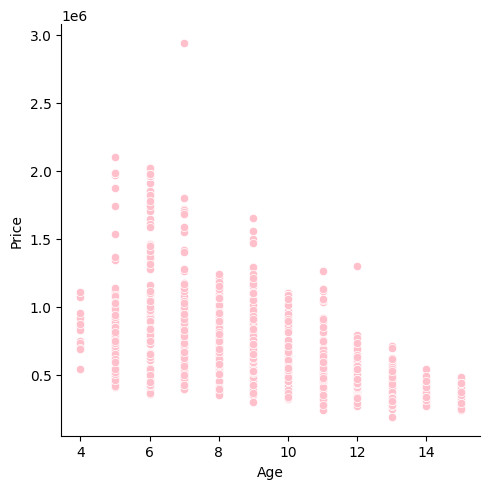

In [160]:
sns.relplot(data = cdf, x = "Age", y = "Price", kind = "scatter", color = "pink")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


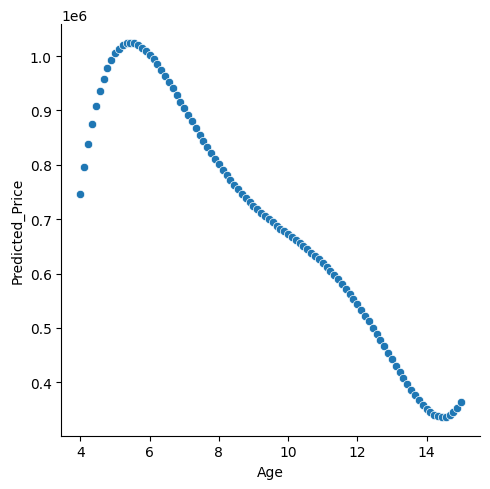

In [159]:
expander = PolynomialFeatures(degree=5,include_bias=False)
X2_poly = expander.fit_transform(X2_p)

model4_ = LinearRegression()
model4_ = model4_.fit(X2_poly, y2_poly)

age_grid = np.linspace(cdf["Age"].min(), cdf["Age"].max(), 100).reshape(-1, 1)
age_grid_poly = expander.transform(age_grid)
    
y_pred = model4_.predict(age_grid_poly)
pred_df = pd.DataFrame({
    "Age": age_grid.flatten(),
    "Predicted_Price": y_pred
})
sns.relplot(data = pred_df, x = "Age", y = "Predicted_Price")

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?\
**a) 4/34 = 0.117**\
**b) 24/69 = 0.347**\
**The ATE on three-year survival for heart transplant interventions is 0.23. This means that heart transplants increase the probability of survival by 23%.**


In [192]:
hdf = pd.read_csv("data/heart_hw.csv")
print(hdf.groupby("transplant")["y"].value_counts().unstack())
print((24/69)-(4/34))

y            0   1
transplant        
control     30   4
treatment   45  24
0.23017902813299232


2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.\
**The slope is basically the same as the the one in part one. The intercept is also the same as survival rate for those in the control group which makes sense because that is just the predicted_y when there is no treatement.**

In [193]:
hy = hdf["y"]
hX = pd.get_dummies(hdf[["transplant"]], drop_first=True)

hmodel = LinearRegression()
hmodel = hmodel.fit(hX, hy)

print("Intercept: ", hmodel.intercept_)
print("Slope: ", hmodel.coef_)

Intercept:  0.11764705882352941
Slope:  [0.23017903]


3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age? What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
**The coefficient for transplant increased by about 0.03 when controlled for age. In this case, the intercept means that the chances of survival when patient is 0 years old is around 70%. The first numbers means that by holding age constant, receiving a transplant increases the chances of survival by 0.26. The second number means that by holding the treatment constant, aging a year would cause the chances of survival to drop by 0.013.**\
**The ATE is underestimating from 0-53ish and overestimating from 53ish to over 60 years of age.  **

In [194]:
hy2 = hdf["y"]
hX2 = pd.concat([pd.get_dummies(hdf[["transplant"]], drop_first = True), hdf[["age"]]], axis = 1)

hmodel2 = LinearRegression()
hmodel2 = hmodel2.fit(hX2, hy2)

print("Intercept: ", hmodel2.intercept_)
print("Slope: ", hmodel2.coef_)

Intercept:  0.7019569721740946
Slope:  [ 0.26470169 -0.01360722]


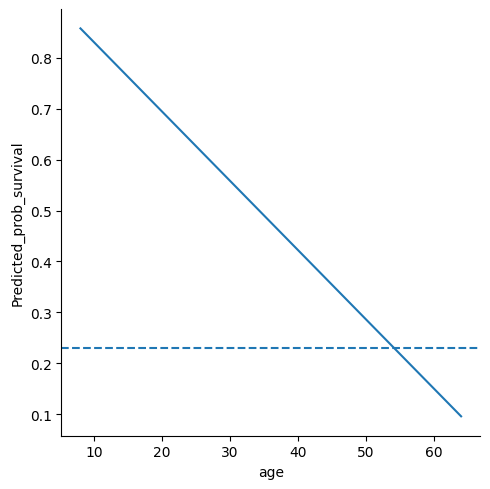

In [195]:
age_grid = np.linspace(hdf["age"].min(), hdf["age"].max(), 100)

pred_df = pd.DataFrame({
    "transplant_treatment": 1,   # or whatever your dummy column is named
    "age": age_grid
})

hy_pred = hmodel2.predict(pred_df)
plot_df = pd.DataFrame({
    "age": age_grid,
    "Predicted_prob_survival": hy_pred
})

g = sns.relplot(data = plot_df, x = "age", y = "Predicted_prob_survival", kind = "line")
ATE = 0.23
g.ax.axhline(y=ATE, linestyle="--")

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?\
**Allowing transplant and age to interact caused the intercept to decrease to 0.35, meaning that the chances of survival for age 0 is 0.35. Holding age constant, the first coefficient means that for every increase in transplant increases the chances of survival for about 0.907. The second number means that holding everything else constant, increasing age by 1 year decreases the chances of survival by 0.005. Lastly, the last coefficient means that the effect of the transplant changed for each additional year of age, decreasing about 0.014.**

In [196]:
hy3 = hdf["y"]
hdf["transplant"] = pd.get_dummies(hdf["transplant"], drop_first=True)
hdf["interaction"] = hdf["transplant"] * hdf["age"]
hX3 = hdf[["transplant", "age", "interaction"]]


hmodel3 = LinearRegression()
hmodel3 = hmodel3.fit(hX3, hy3)

print("Intercept: ", hmodel3.intercept_)
print("Slope: ", hmodel3.coef_)

Intercept:  0.35486517529945866
Slope:  [ 0.90775139 -0.00552426 -0.01459064]


5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.\
**Model 3 (with interactions) had the lowest mean squared error, though not by much. They are slightly more accurate than the first and second model.**


In [197]:
kfold = KFold(n_splits=10, shuffle=True, random_state=100) # Create folds

scores = cross_val_score( # Conduct kfcv:
    hmodel,hX,hy, # Model and data
    cv=kfold, # Folds
    scoring= "neg_mean_squared_error"
)
print("Fold scores:", -scores)
print("Mean score:", np.mean(-scores))
print("Std dev:", np.std(-scores))
print()

scores = cross_val_score( # Conduct kfcv:
    hmodel2,hX2,hy2, # Model and data
    cv=kfold, # Folds
    scoring= "neg_mean_squared_error"
)
print("Fold scores:", -scores)
print("Mean score:", np.mean(-scores))
print("Std dev:", np.std(-scores))
print()

scores = cross_val_score( # Conduct kfcv:
    hmodel3,hX3,hy3, # Model and data
    cv=kfold, # Folds
    scoring= "neg_mean_squared_error"
)
print("Fold scores:", -scores)
print("Mean score:", np.mean(-scores))
print("Std dev:", np.std(-scores))


Fold scores: [0.18821929 0.09540463 0.25155303 0.18834547 0.27505257 0.17580257
 0.23480257 0.20624315 0.09155851 0.22965661]
Mean score: 0.1936638397901797
Std dev: 0.057947149896073094

Fold scores: [0.13199021 0.09724379 0.23532537 0.17986301 0.26846931 0.13026885
 0.15561234 0.21528362 0.17469232 0.22844789]
Mean score: 0.18171967184387974
Std dev: 0.051671984999242804

Fold scores: [0.13045006 0.09902894 0.233215   0.25380574 0.27583732 0.11557048
 0.12649585 0.20870022 0.14792529 0.21568012]
Mean score: 0.18067090272965364
Std dev: 0.0605064791938699


6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?\
**My main issue is the use of predictive models to determine who gets a transplant first. This feels a little unethical because we are eventually going to prioritize people with certain characteristics over others. This may not seem fair to patients because they cannot control something like age. In addition, our model is only built upon age and transplant. Many other factors should be accounted for if predictions must be accurate.**